# Bài tập thực hành tuần 1
> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH_KDL2

This is a dataset related to how much money a person can get from a mortgage on his or her home. This dataset includes the following features:
* Gender: Gender of the borrower (including two values 'F' and 'M')
* Age: Age of the customer applying for a loan (including positive integer values)
* Income (USD): Customer's income in USD (value is a positive number)
* Income Stability: The level of customer's income stability (including three values of Low and High)
* Property Age: Life expectancy of the house in days (including positive integer values)
* Property Location: Location of the house (including 'Rural', 'Urban', and 'Semi-Urban')
* Property Price: The value of the house in USD (including positive real values)
* Loan Sanction Amount (USD): Amount that customers can borrow in USD (target value)

Based on practice sample #1, proceed:
1. Read data
2. Visualize some information of data
3. Normalize Data (Feature Engineering) to train linear regression model
4. Train linear regression model and show the model's intercepts, coeficients
5. Learn on sklearn how to use Ridge, Lasso, and ElasticNet compare the error of all 3 algorithms with Linear Regression (https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
6. Let's try Polynomial of order 2 to compare the previous results. What will the result be if we choose the n order too high?


In [1]:
#import library
import pandas as pd # pandas
import numpy as np # numpy
import seaborn as sns # seaborn
import matplotlib.pyplot as plt # matplotlib
import time
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn import linear_model




# 1. Read Data

In [2]:
# read data using Pandas DataFrame
def read_dataset(path):
    df = pd.read_csv(path)
    display(df.head())
    print("\nDataFrame Info:")
    print(df.info())
    print("\nDataFrame Shape:", df.shape)
    display(df.describe())
    return df

In [ ]:
path = r"D:\Introduction-to-Machine-Learning_MTH10353\Homework\1\final_house_loan.csv"


In [4]:
df = read_dataset(path)

,Gender,Age,Income (USD),Income Stability,Property Age,Property Location,Property Price,Loan Sanction Amount (USD)
0,F,19,1641.25,Low,1651.25,Rural,59641.82,21026.420753
1,M,29,1989.71,Low,1990.71,Urban,179858.51,60595.183366
2,F,37,1849.91,Low,1856.91,Rural,117297.62,39181.648002
3,M,65,2735.18,High,2747.18,Rural,354417.72,128497.710865
4,F,62,4741.78,High,4740.78,Urban,82049.80,39386.919336



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47297 entries, 0 to 47296
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gender                      47297 non-null  object 
 1   Age                         47297 non-null  int64  
 2   Income (USD)                47265 non-null  float64
 3   Income Stability            47285 non-null  object 
 4   Property Age                47263 non-null  float64
 5   Property Location           47294 non-null  object 
 6   Property Price              47297 non-null  float64
 7   Loan Sanction Amount (USD)  47297 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.9+ MB
None

DataFrame Shape: (47297, 8)


,Age,Income (USD),Property Age,Property Price,Loan Sanction Amount (USD)
count,47297.000000,47265.000000,47263.000000,4.729700e+04,47297.000000
mean,40.000063,2586.684384,2586.611058,1.350880e+05,46487.229765
std,16.086128,1558.768809,1558.842286,9.457875e+04,32549.905634
min,18.000000,372.700000,370.700000,7.859620e+03,254.586578
25%,24.000000,1653.740000,1652.820000,6.250408e+04,21782.822159
50%,40.000000,2245.480000,2244.810000,1.130936e+05,38822.132402
75%,55.000000,3128.560000,3128.380000,1.819546e+05,62612.236905
max,65.000000,54662.750000,54647.750000,1.077967e+06,366131.165218


# 2. Visualize some information of data

**Extra:**  check missing values & null values


In [5]:
# Check for missing values in the dataset
print("Missing values summary:")
display(df.isnull().sum())

Missing values summary:


Gender                         0
Age                            0
Income (USD)                  32
Income Stability              12
Property Age                  34
Property Location              3
Property Price                 0
Loan Sanction Amount (USD)     0
dtype: int64

In [6]:
def preprocessing_data(df):
    # fill missing values with mean for numeric columns
    df = df.fillna(df.mean(numeric_only=True))
    # fill missing values with mode for categorical columns
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode().iloc[0])
    return df

df = preprocessing_data(df)
print("Missing values after preprocessing:")
display(df.isnull().sum())

Missing values after preprocessing:


Gender                        0
Age                           0
Income (USD)                  0
Income Stability              0
Property Age                  0
Property Location             0
Property Price                0
Loan Sanction Amount (USD)    0
dtype: int64

Visualize the distribution of data using histograms and boxplots to understand the spread and identify any potential outliers.

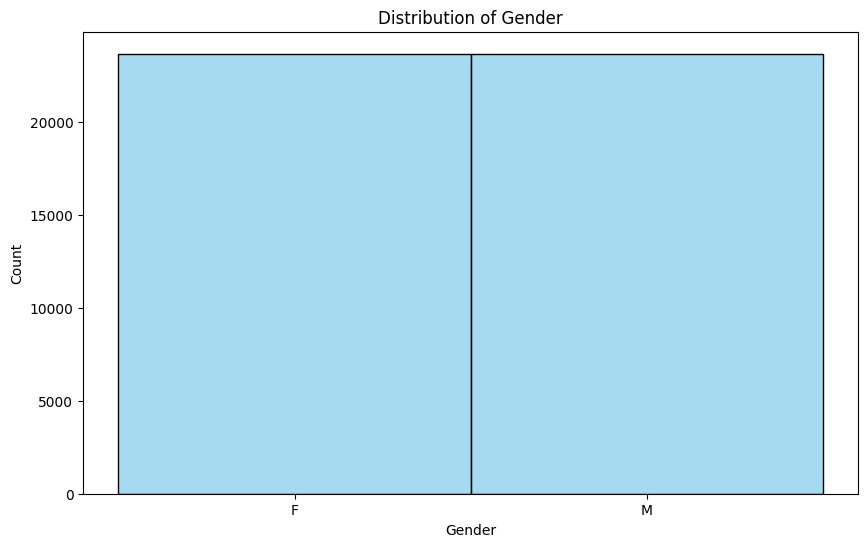

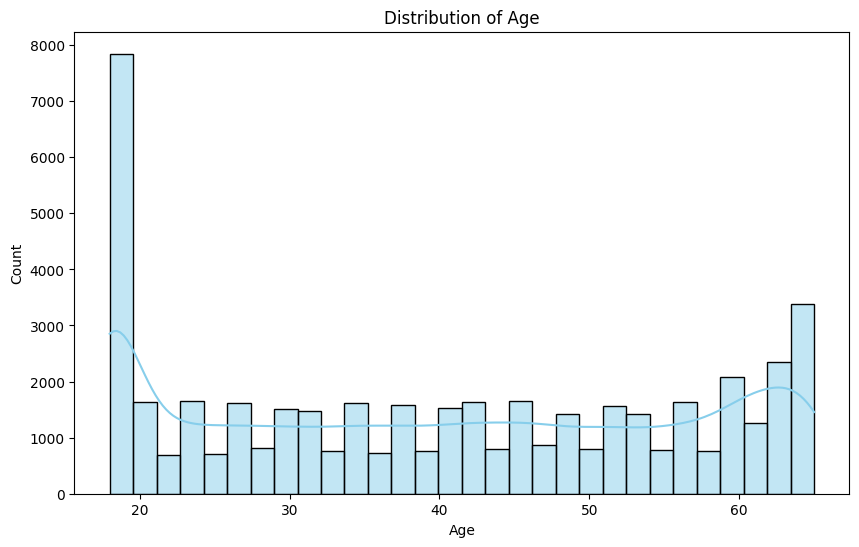

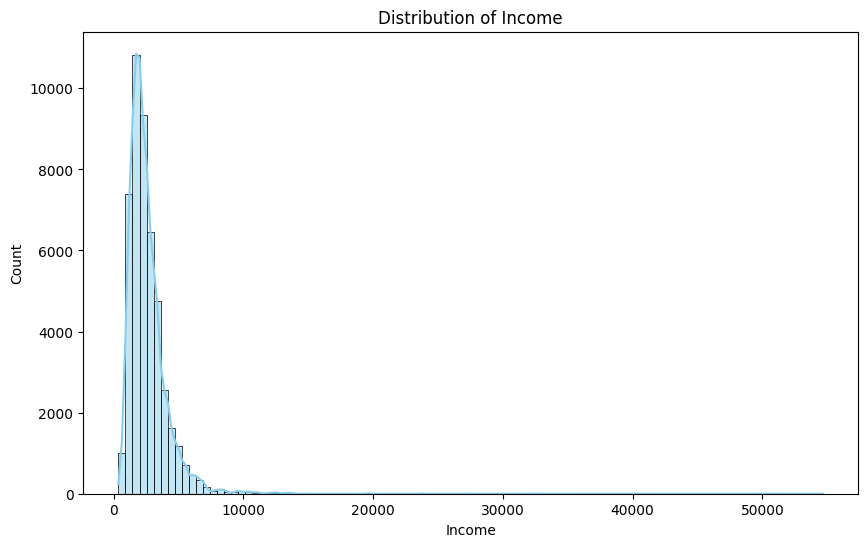

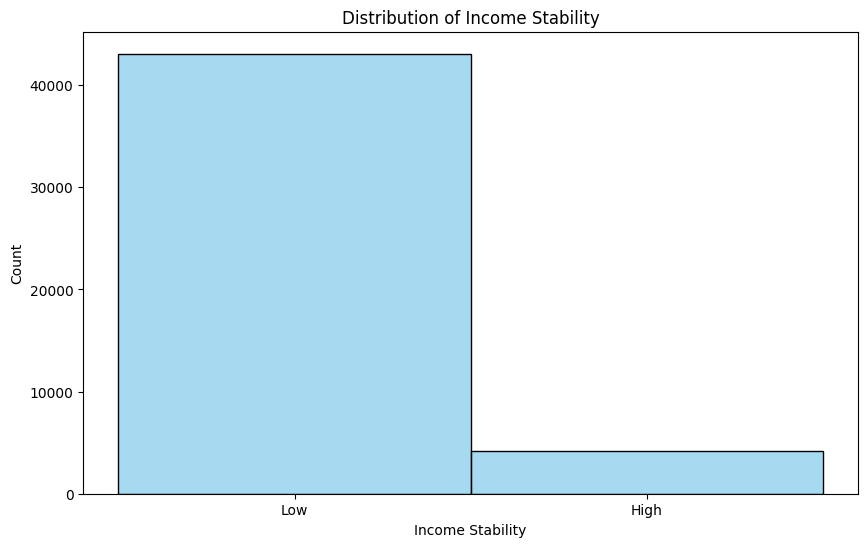

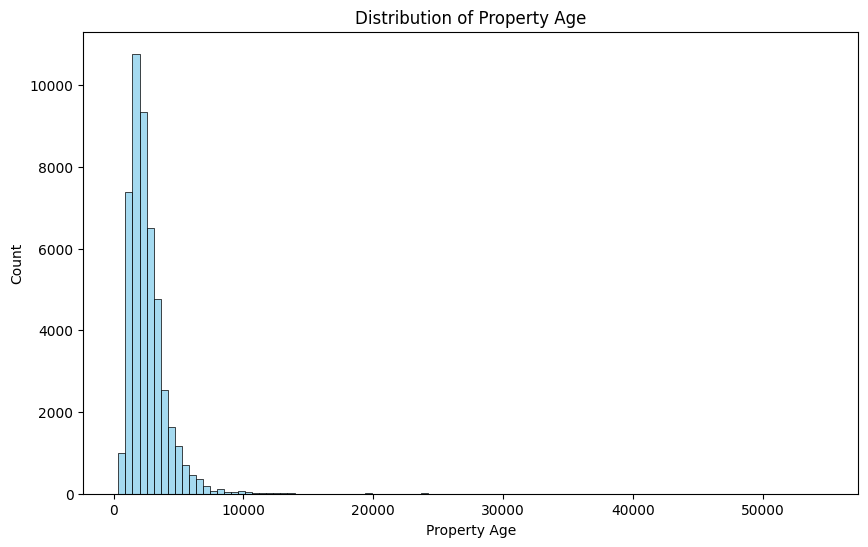

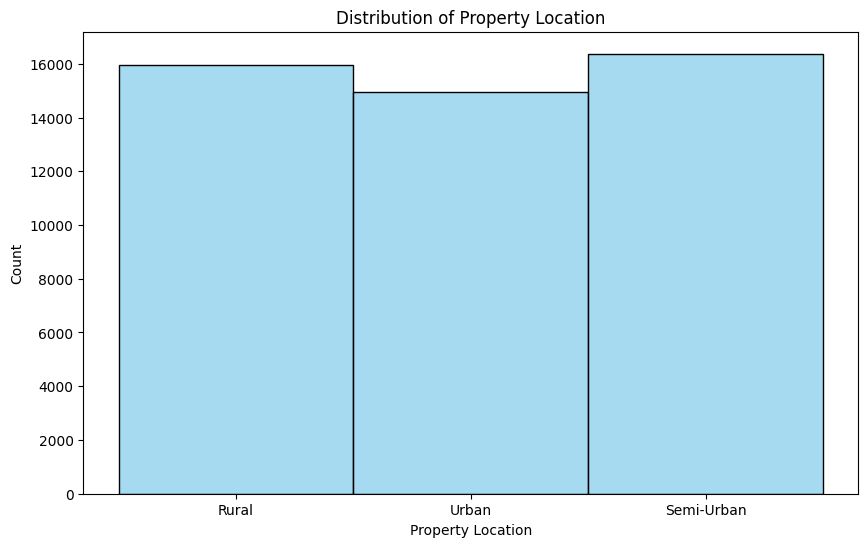

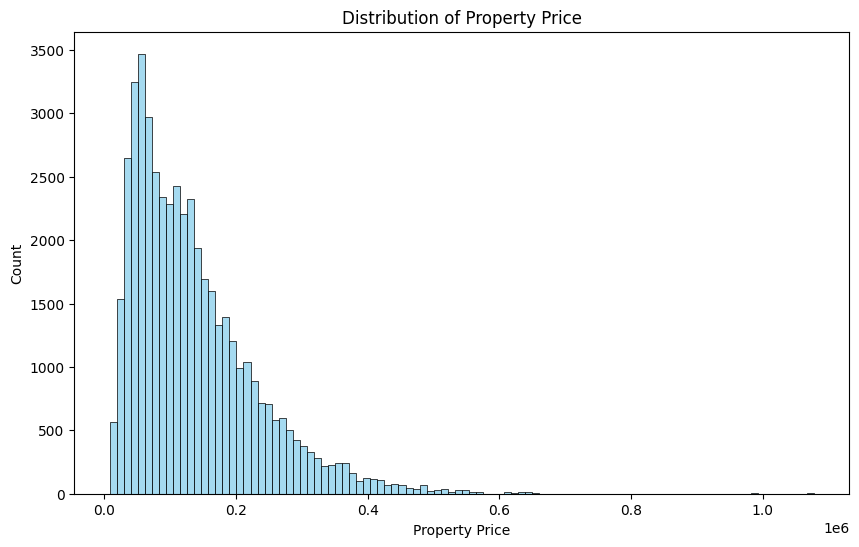

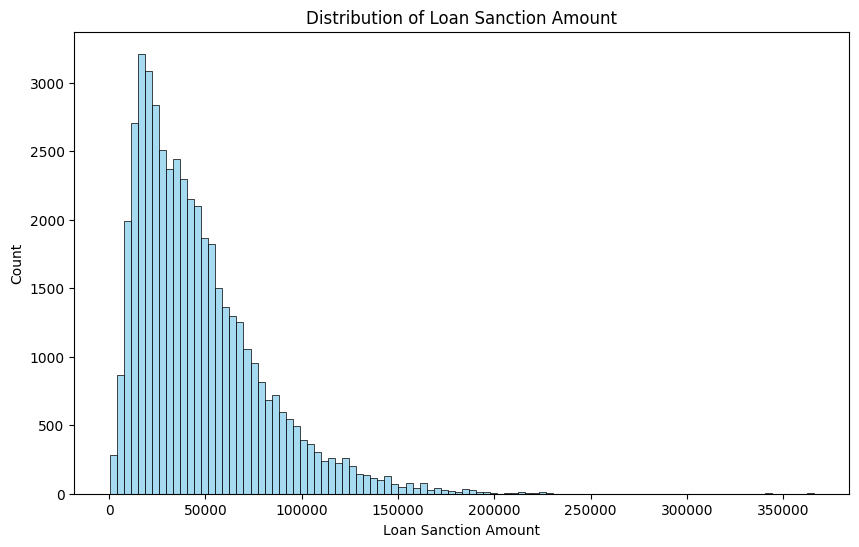

In [7]:
# histograms
plt.figure(figsize=(10, 6))
sns.histplot(df['Gender'], kde=False, bins=2, color='skyblue')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['Income (USD)'], kde=True, bins=100, color='skyblue')
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['Income Stability'], kde=False, bins=2, color='skyblue')
plt.title('Distribution of Income Stability')
plt.xlabel('Income Stability')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['Property Age'], kde=False, bins=100, color='skyblue')
plt.title('Distribution of Property Age')
plt.xlabel('Property Age')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['Property Location'], kde=False, bins=3, color='skyblue')
plt.title('Distribution of Property Location')
plt.xlabel('Property Location')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['Property Price'], kde=False, bins=100, color='skyblue')
plt.title('Distribution of Property Price')
plt.xlabel('Property Price')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['Loan Sanction Amount (USD)'], kde=False, bins=100, color='skyblue')
plt.title('Distribution of Loan Sanction Amount')
plt.xlabel('Loan Sanction Amount')
plt.ylabel('Count')
plt.show()

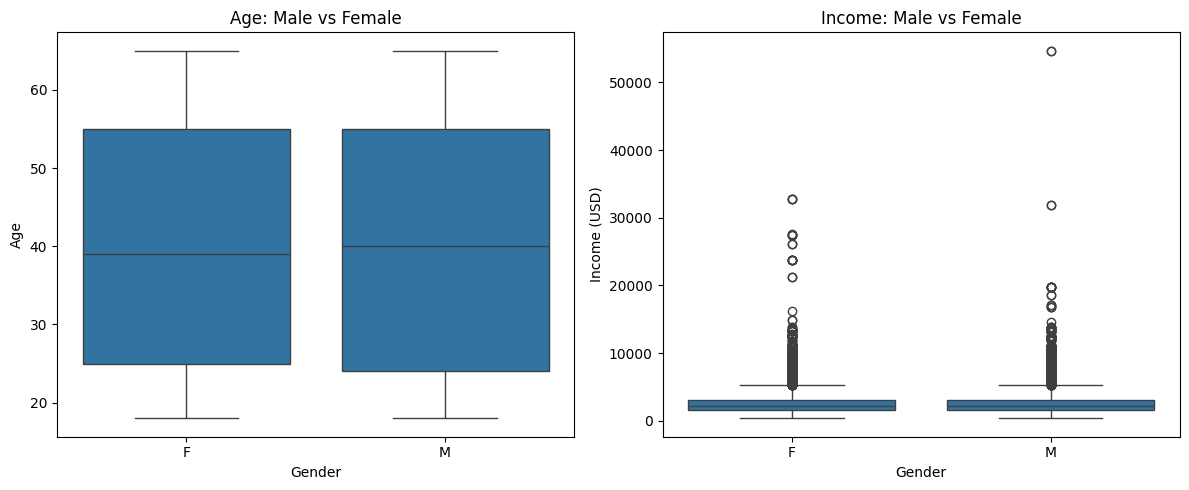

In [8]:
#boxplots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Gender', y='Age', data=df)
plt.title('Age: Male vs Female')

plt.subplot(1, 2, 2)
sns.boxplot(x='Gender', y='Income (USD)', data=df)
plt.title('Income: Male vs Female')

plt.tight_layout()
plt.show()

# 3. Normalize Data (Feature Engineering) to train linear regression model

In [9]:
def normalize_data(df):
  normalized_data = df.copy()
  normalized_data["Gender"] = normalized_data["Gender"].astype("category").cat.codes
  normalized_data["Income Stability"] = normalized_data["Income Stability"].astype("category").cat.codes
  normalized_data["Property Location"] = normalized_data["Property Location"].astype("category").cat.codes
  normalized_data["Age"] = zscore(normalized_data["Age"])
  normalized_data["Income (USD)"] = zscore(normalized_data["Income (USD)"])
  normalized_data["Property Age"] = zscore(normalized_data["Property Age"])
  normalized_data["Property Price"] = zscore(normalized_data["Property Price"])
  
  display(normalized_data.head())
  display(normalized_data.corr())
  return normalized_data

,Gender,Age,Income (USD),Income Stability,Property Age,Property Location,Property Price,Loan Sanction Amount (USD)
0,0,-1.305490,-0.606738,1,-0.600258,0,-0.797716,21026.420753
1,1,-0.683830,-0.383112,1,-0.382413,2,0.473372,60595.183366
2,0,-0.186502,-0.472829,1,-0.468278,0,-0.188104,39181.648002
3,1,1.554147,0.095298,0,0.103043,0,2.319041,128497.710865
4,0,1.367649,1.383045,0,1.382415,2,-0.560790,39386.919336


,Gender,Age,Income (USD),Income Stability,Property Age,Property Location,Property Price,Loan Sanction Amount (USD)
Gender,1.000000,0.007725,-0.002613,-0.019062,-0.002706,0.009106,0.005980,0.003493
Age,0.007725,1.000000,-0.044046,-0.455781,-0.044012,-0.007755,-0.003330,-0.000319
Income (USD),-0.002613,-0.044046,1.000000,0.080917,0.999973,-0.000158,0.357952,0.392658
Income Stability,-0.019062,-0.455781,0.080917,1.000000,0.080957,-0.001884,0.004823,-0.070777
Property Age,-0.002706,-0.044012,0.999973,0.080957,1.000000,-0.000216,0.357929,0.392591
Property Location,0.009106,-0.007755,-0.000158,-0.001884,-0.000216,1.000000,-0.000695,-0.001797
Property Price,0.005980,-0.003330,0.357952,0.004823,0.357929,-0.000695,1.000000,0.994240
Loan Sanction Amount (USD),0.003493,-0.000319,0.392658,-0.070777,0.392591,-0.001797,0.994240,1.000000


<Axes: >

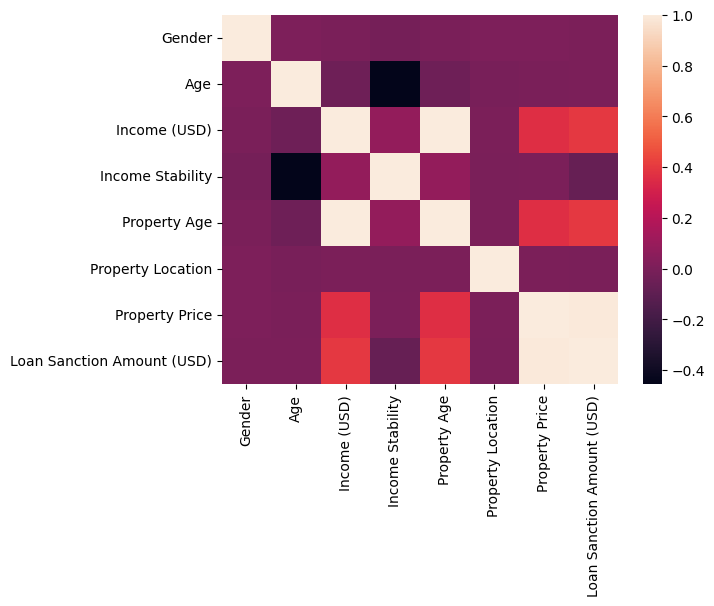

In [10]:
# Heatmap
normalized_data = normalize_data(df)
sns.heatmap(normalized_data.corr())

# 4. Train linear regression model and show the model's intercepts, coeficients

In [11]:
# Train-test split
columns = df.columns.tolist()
columns

['Gender',
 'Age',
 'Income (USD)',
 'Income Stability',
 'Property Age',
 'Property Location',
 'Property Price',
 'Loan Sanction Amount (USD)']

In [12]:
def prepare_X_y(df):
    ## Split X, y from dataset
    columns = df.columns.tolist()     # Columns name
    columns.remove('Loan Sanction Amount (USD)')           # Remove y label (column charges in this case)
    # columns = ["smoker_yes", "bmi", "age"]
    X = df[columns]        # X
    y = df['Loan Sanction Amount (USD)']          # y
    return X, y

X, y = prepare_X_y(normalized_data)

In [13]:
def split_train_test(X, y, train_size=0.7):
    trainX, testX ,trainY, testY = train_test_split(X, y, train_size=train_size, random_state=2026)
    print('Training:' + str(trainX.shape))
    print('Test:' + str(testX.shape))

    return trainX, testX ,trainY, testY

trainX, testX ,trainY, testY = split_train_test(X, y)

Training:(33107, 7)
Test:(14190, 7)


In [14]:
# Basic Linear Regression
def build_linear_model(X, y):
    model = linear_model.LinearRegression(fit_intercept=True)
    model.fit(X, y)

    return model

model = build_linear_model(trainX, trainY)
# Compare on training dataset
pred = model.predict(trainX)
print("mean absolute error of linear model on train set ", mean_absolute_error(y_pred=pred, y_true=trainY) )
pred = model.predict(testX)
print("mean absolute error of linear model on test set ", mean_absolute_error(y_pred=pred, y_true=testY) )
print("Model Coefficients:")
print(model.coef_) # print coefficient
print("Model Intercept:")
print(model.intercept_) # print intercept_


mean absolute error of linear model on train set  226.57007268056756
mean absolute error of linear model on test set  224.5563257769385
Model Coefficients:
[  -269.06129635  -1280.69124668  25850.74320946 -11143.70082733
 -24251.09785901    -64.36585635  31806.79484037]
Model Intercept:
56837.31231784763


# 5. Learn on sklearn how to use Ridge, Lasso, and ElasticNet compare the error of all 3 algorithms with Linear Regression (https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

In [15]:

# Learn on sklearn how to use Ridge, Lasso, and ElasticNet compare the error of all 3 algorithms with Linear Regression 

# Ridge Regression
def build_ridge_model(X, y, alpha=1.0):
    model = linear_model.Ridge(alpha=alpha, fit_intercept=True)
    model.fit(X, y)

    return model

ridge = build_ridge_model(trainX, trainY, alpha=1.0)
# Compare on training dataset
predTrain = ridge.predict(trainX)
print("mean absolute error of ridge model on train set ", mean_absolute_error(y_pred=predTrain, y_true=trainY) )
predTest = ridge.predict(testX)
print("mean absolute error of ridge model on test set ", mean_absolute_error(y_pred=predTest, y_true=testY) )
print("Model Coefficients:")
print(ridge.coef_) # print coefficient
print("Model Intercept:")
print(ridge.intercept_) # print intercept_

# Compare with Linear Regression and Ridge Regression
print("Linear Regression vs Ridge Regression:")
diff = mean_absolute_error(y_pred=ridge.predict(testX), y_true=testY) - mean_absolute_error(y_pred=linear_model.LinearRegression().fit(trainX, trainY).predict(testX), y_true=testY)
print("Difference in mean absolute error (Ridge - Linear):", diff)


mean absolute error of ridge model on train set  194.2686014863681
mean absolute error of ridge model on test set  193.07333599650983
Model Coefficients:
[  -265.83993676  -1280.62488935  13755.6671518  -11141.03395816
 -12155.98347596    -63.38529125  31806.05488267]
Model Intercept:
56832.58623741309
Linear Regression vs Ridge Regression:
Difference in mean absolute error (Ridge - Linear): -31.48298978042868


In [16]:

# Lasso Regression
def build_lasso_model(X, y, alpha=1.0):
    model = linear_model.Lasso(alpha=alpha, fit_intercept=True, max_iter=10000, tol=0.01)
    model.fit(X, y) 
    
    return model

lasso = build_lasso_model(trainX, trainY, alpha=1.0)
# Compare on training dataset
predTrain = lasso.predict(trainX)
print("mean absolute error of lasso model on train set ", mean_absolute_error(y_pred=predTrain, y_true=trainY) )
predTest = lasso.predict(testX)
print("mean absolute error of lasso model on test set ", mean_absolute_error(y_pred=predTest, y_true=testY) )
print("Model Coefficients:")
print(lasso.coef_) # print coefficient
print("Model Intercept:")
print(lasso.intercept_) # print intercept_

# Compare with Linear Regression and Lasso Regression
print("Linear Regression vs Lasso Regression:")
diff = mean_absolute_error(y_pred=lasso.predict(testX), y_true=testY) - mean_absolute_error(y_pred=linear_model.LinearRegression().fit(trainX, trainY).predict(testX), y_true=testY)
print("Difference in mean absolute error (Lasso - Linear):", diff)


mean absolute error of lasso model on train set  178.15440066549348
mean absolute error of lasso model on test set  177.7515958519659
Model Coefficients:
[  -255.68834389  -1257.06360813   1378.46716004 -11102.17547136
    244.28375167    -60.83435945  31797.88750978]
Model Intercept:
56789.98350187356
Linear Regression vs Lasso Regression:
Difference in mean absolute error (Lasso - Linear): -46.804729924972605


In [17]:
# ElasticNet Regression
def build_elasticnet_model(X, y, alpha=1.0, l1_ratio=1):
    model = linear_model.ElasticNet(alpha=alpha, l1_ratio=l1_ratio, fit_intercept=True, max_iter=10000, tol=0.01)
    model.fit(X, y)
    
    return model

elasticnet = build_elasticnet_model(trainX, trainY, alpha=1.0, l1_ratio=0.5)
# Compare on training dataset
predTrain = elasticnet.predict(trainX)
print("mean absolute error of elasticnet model on train set ", mean_absolute_error(y_pred=predTrain, y_true=trainY) )
predTest = elasticnet.predict(testX)
print("mean absolute error of elasticnet model on test set ", mean_absolute_error(y_pred=predTest, y_true=testY) )
print("Model Coefficients:")
print(elasticnet.coef_) # print coefficient
print("Model Intercept:")
print(elasticnet.intercept_) # print intercept_

# Compare with Linear Regression and ElasticNet Regression
print("Linear Regression vs ElasticNet Regression:")
diff = mean_absolute_error(y_pred=elasticnet.predict(testX), y_true=testY) - mean_absolute_error(y_pred=linear_model.LinearRegression().fit(trainX, trainY).predict(testX), y_true=testY)
print("Difference in mean absolute error (ElasticNet - Linear):", diff)


mean absolute error of elasticnet model on train set  8432.979855248826
mean absolute error of elasticnet model on test set  8520.82434996211
Model Coefficients:
[ 1.25206812e+01  6.80946661e+01  2.19673401e+03 -1.34375168e+03
  2.19298302e+03 -4.05758424e+01  2.04945229e+04]
Model Intercept:
47779.05268033265
Linear Regression vs ElasticNet Regression:
Difference in mean absolute error (ElasticNet - Linear): 8296.26802418517


**Extra:** Finding best parameters for Ridge, Lasso, and ElasticNet 

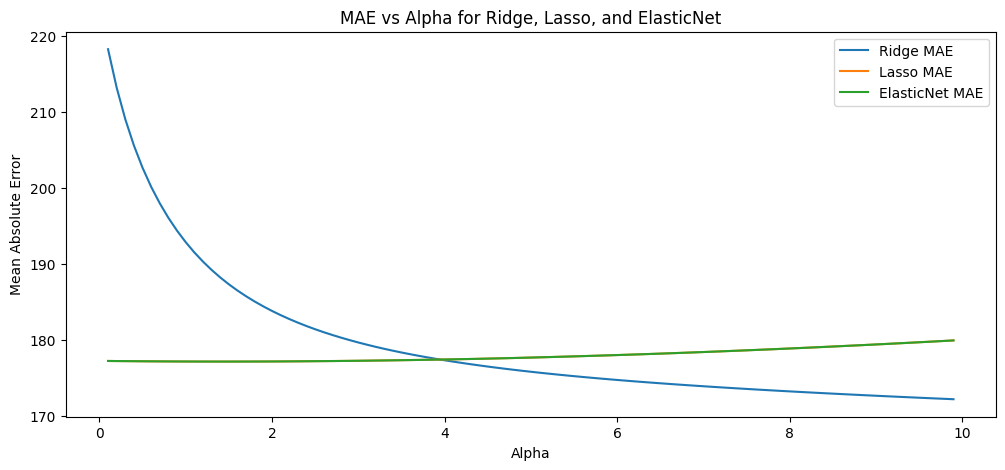

Best alpha for Ridge: 9.90, best MAE: 172.2273, improvement over Linear: 52.3291
Best alpha for Lasso: 1.50, best MAE: 177.1831, improvement over Linear: 47.3733
Best alpha for ElasticNet: 1.50, best MAE: 177.1831, improvement over Linear: 47.3733


In [18]:
alphas = np.arange(0.1, 10, 0.1)

mae_ridge = []
mae_lasso = []
mae_elasticnet = []
# Scale data
scaler = StandardScaler()
trainX_scaled = scaler.fit_transform(trainX)
testX_scaled = scaler.transform(testX)

for i in alphas:
    ridge = build_ridge_model(trainX_scaled, trainY, alpha=i)
    predTest = ridge.predict(testX_scaled)
    mae_ridge.append(mean_absolute_error(y_pred=predTest, y_true=testY))
    
    lasso = build_lasso_model(trainX_scaled, trainY, alpha=i)
    predTest = lasso.predict(testX_scaled)
    mae_lasso.append(mean_absolute_error(y_pred=predTest, y_true=testY))
    
    elasticnet = build_elasticnet_model(trainX_scaled, trainY, alpha=i, l1_ratio=1)
    predTest = elasticnet.predict(testX_scaled)
    mae_elasticnet.append(mean_absolute_error(y_pred=predTest, y_true=testY))
    
plt.figure(figsize=(12, 5))
plt.plot(alphas, mae_ridge, label='Ridge MAE')
plt.plot(alphas, mae_lasso, label='Lasso MAE')
plt.plot(alphas, mae_elasticnet, label='ElasticNet MAE')
plt.xlabel('Alpha')
plt.ylabel('Mean Absolute Error')
plt.title('MAE vs Alpha for Ridge, Lasso, and ElasticNet')
plt.legend()
plt.show()

best_alpha_ridge = alphas[np.argmin(mae_ridge)]
best_alpha_lasso = alphas[np.argmin(mae_lasso)]
best_alpha_elasticnet = alphas[np.argmin(mae_elasticnet)]

best_mae_ridge = min(mae_ridge)
best_mae_lasso = min(mae_lasso)
best_mae_elasticnet = min(mae_elasticnet)

baseline_model = linear_model.LinearRegression().fit(trainX_scaled, trainY)
mae_linear = mean_absolute_error(y_pred=baseline_model.predict(testX_scaled), y_true=testY)

print(f"Best alpha for Ridge: {best_alpha_ridge:.2f}, best MAE: {best_mae_ridge:.4f}, improvement over Linear: {mae_linear - best_mae_ridge:.4f}")
print(f"Best alpha for Lasso: {best_alpha_lasso:.2f}, best MAE: {best_mae_lasso:.4f}, improvement over Linear: {mae_linear - best_mae_lasso:.4f}")
print(f"Best alpha for ElasticNet: {best_alpha_elasticnet:.2f}, best MAE: {best_mae_elasticnet:.4f}, improvement over Linear: {mae_linear - best_mae_elasticnet:.4f}")

Như vậy giữa các phương pháp Ridge, Lasso, và ElasticNet thì cả 3 đều có thể cải thiện hiệu suất của mô hình so với Linear Regression.

# 6. Let's try Polynomial of order 2 to compare the previous results. What will the result be if we choose the n order too high?

In [19]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

> **Note:** Do n chạy từ 2 đến 8 nên đã thoả mãn yêu cầu **"Let's try Polynomial of order 2 to compare the previous results"**, n còn lại là để lý giải cho câu hỏi **"What will the result be if we choose the n order too high?"**

mean absolute error of linear model (with poly transform n = 2) on train set  154.94268406042352
mean absolute error of linear model (with poly transform n = 2) on test set  154.20644067428057
mean absolute error of linear model (with poly transform n = 3) on train set  176.24686979121938
mean absolute error of linear model (with poly transform n = 3) on test set  180.7012052500581
mean absolute error of linear model (with poly transform n = 4) on train set  186.41994049898528
mean absolute error of linear model (with poly transform n = 4) on test set  195.21787088785246
mean absolute error of linear model (with poly transform n = 5) on train set  199.32330138778107
mean absolute error of linear model (with poly transform n = 5) on test set  221.48322216925465
mean absolute error of linear model (with poly transform n = 6) on train set  196.69163462416952
mean absolute error of linear model (with poly transform n = 6) on test set  523.6075849836524
mean absolute error of linear model (

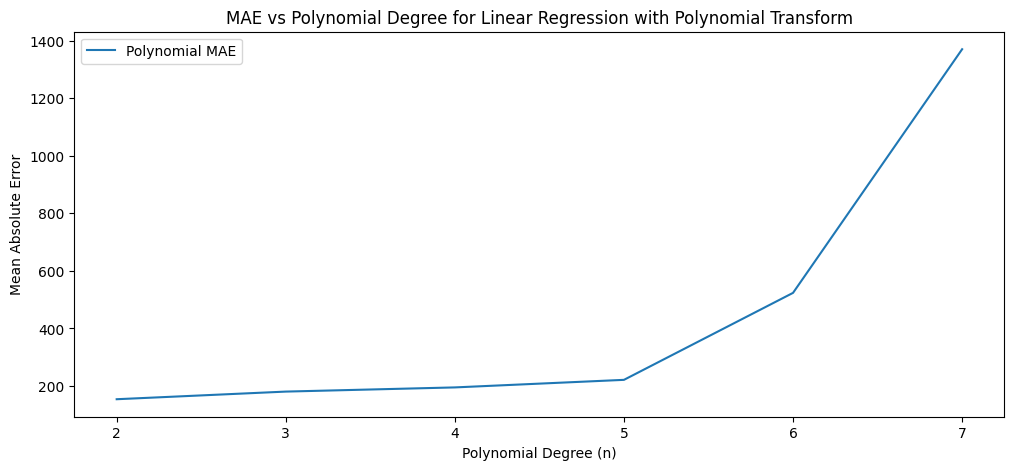

In [20]:
#Linear Regression with Polynomial Transform
def build_pipeline(X, y, n = 2):
    poly_model = make_pipeline(PolynomialFeatures(n, include_bias=False), LinearRegression()) # use make_pipeline to apply PolynomialFeatures and a Regression model train your dataset
    poly_model.fit(X, y)  

    return poly_model
mae_poly = []
for n in range(2, 8):
    poly_model = build_pipeline(trainX, trainY,n)
    # Compare on training dataset
    poly_pred = poly_model.predict(trainX)
    print(f"mean absolute error of linear model (with poly transform n = {n}) on train set ", mean_absolute_error(y_pred=poly_pred, y_true=trainY) )

    poly_pred = poly_model.predict(testX)
    print(f"mean absolute error of linear model (with poly transform n = {n}) on test set ", mean_absolute_error(y_pred=poly_pred, y_true=testY))
    mae_poly.append(mean_absolute_error(y_pred=poly_pred, y_true=testY))
    
plt.figure(figsize=(12, 5))
plt.plot(range(2, 8), mae_poly, label='Polynomial MAE')
plt.xlabel('Polynomial Degree (n)')
plt.ylabel('Mean Absolute Error')
plt.title('MAE vs Polynomial Degree for Linear Regression with Polynomial Transform')
plt.legend()
plt.show()


mean absolute error of linear model (with poly transform n = 2) on train set  168.4569653476946
mean absolute error of linear model (with poly transform n = 2) on test set  166.95063642948384
mean absolute error of linear model (with poly transform n = 3) on train set  169.2457119824141
mean absolute error of linear model (with poly transform n = 3) on test set  168.87423275481814
mean absolute error of linear model (with poly transform n = 4) on train set  174.59691301652958
mean absolute error of linear model (with poly transform n = 4) on test set  174.802071068249
mean absolute error of linear model (with poly transform n = 5) on train set  185.78462628798127
mean absolute error of linear model (with poly transform n = 5) on test set  189.28595330797324
mean absolute error of linear model (with poly transform n = 6) on train set  195.03793211691323
mean absolute error of linear model (with poly transform n = 6) on test set  242.25387016982754
mean absolute error of linear model (wi

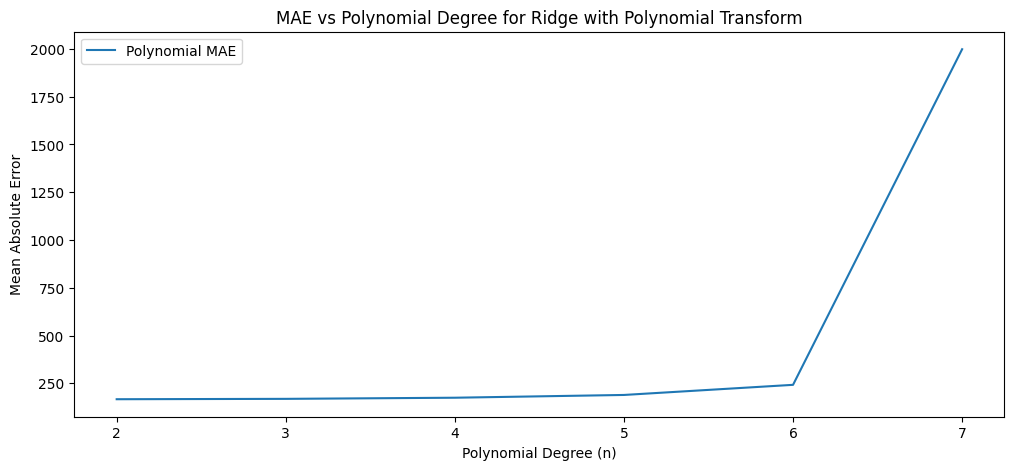

In [21]:
#Ridge
def build_pipeline_ridge(X, y, n = 2):
    poly_model = make_pipeline(PolynomialFeatures(n, include_bias=False), linear_model.Ridge()) # use make_pipeline to apply PolynomialFeatures and a Regression model train your dataset
    poly_model.fit(X, y)  

    return poly_model

mae_poly = []
for n in range(2, 8):
    poly_model = build_pipeline_ridge(trainX, trainY,n)
    # Compare on training dataset
    poly_pred = poly_model.predict(trainX)
    print(f"mean absolute error of linear model (with poly transform n = {n}) on train set ", mean_absolute_error(y_pred=poly_pred, y_true=trainY) )

    poly_pred = poly_model.predict(testX)
    print(f"mean absolute error of linear model (with poly transform n = {n}) on test set ", mean_absolute_error(y_pred=poly_pred, y_true=testY))
    mae_poly.append(mean_absolute_error(y_pred=poly_pred, y_true=testY))
    
plt.figure(figsize=(12, 5))
plt.plot(range(2, 8), mae_poly, label='Polynomial MAE')
plt.xlabel('Polynomial Degree (n)')
plt.ylabel('Mean Absolute Error')
plt.title('MAE vs Polynomial Degree for Ridge with Polynomial Transform')
plt.legend()
plt.show()


mean absolute error of linear model (with poly transform n = 2) on train set  677.971457981106
mean absolute error of linear model (with poly transform n = 2) on test set  671.0562956862939
mean absolute error of linear model (with poly transform n = 3) on train set  882.8666163438783
mean absolute error of linear model (with poly transform n = 3) on test set  884.4218612909837
mean absolute error of linear model (with poly transform n = 4) on train set  619.005397739723
mean absolute error of linear model (with poly transform n = 4) on test set  624.772534277095
mean absolute error of linear model (with poly transform n = 5) on train set  509.8118174098543
mean absolute error of linear model (with poly transform n = 5) on test set  517.6318177013441
mean absolute error of linear model (with poly transform n = 6) on train set  428.11902741601114
mean absolute error of linear model (with poly transform n = 6) on test set  437.3834523748148
mean absolute error of linear model (with poly 

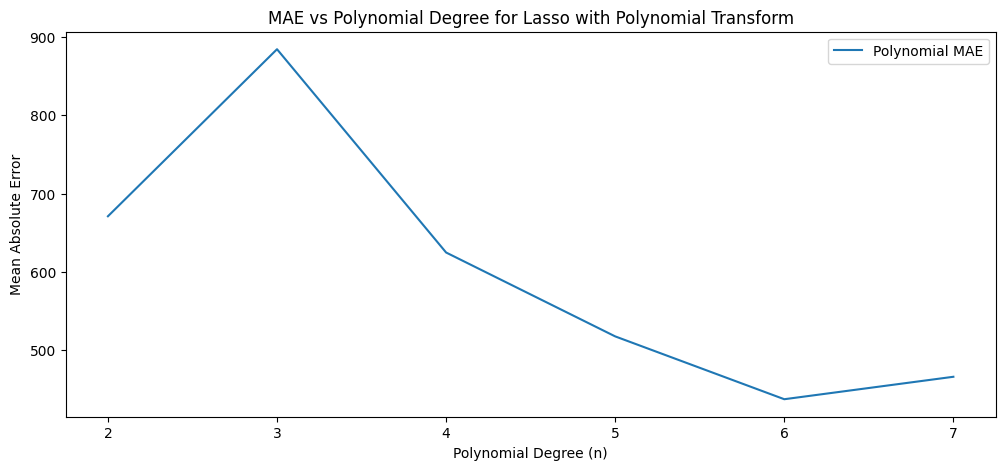

In [22]:
# Lasso

def build_pipeline_lasso(X, y, n = 2):
    poly_model = make_pipeline(PolynomialFeatures(n, include_bias=False), linear_model.Lasso(alpha=1.0, fit_intercept=True, max_iter=10000, tol=0.01)) # use make_pipeline to apply PolynomialFeatures and a Regression model train your dataset
    poly_model.fit(X, y)  

    return poly_model


mae_poly = []
for n in range(2, 8):
    poly_model = build_pipeline_lasso(trainX, trainY,n)
    # Compare on training dataset
    poly_pred = poly_model.predict(trainX)
    print(f"mean absolute error of linear model (with poly transform n = {n}) on train set ", mean_absolute_error(y_pred=poly_pred, y_true=trainY) )

    poly_pred = poly_model.predict(testX)
    print(f"mean absolute error of linear model (with poly transform n = {n}) on test set ", mean_absolute_error(y_pred=poly_pred, y_true=testY))
    mae_poly.append(mean_absolute_error(y_pred=poly_pred, y_true=testY))
    
plt.figure(figsize=(12, 5))
plt.plot(range(2, 8), mae_poly, label='Polynomial MAE')
plt.xlabel('Polynomial Degree (n)')
plt.ylabel('Mean Absolute Error')
plt.title('MAE vs Polynomial Degree for Lasso with Polynomial Transform')
plt.legend()
plt.show()

mean absolute error of linear model (with poly transform n = 2) on train set  677.971457981106
mean absolute error of linear model (with poly transform n = 2) on test set  671.0562956862939
mean absolute error of linear model (with poly transform n = 3) on train set  882.8666163438783
mean absolute error of linear model (with poly transform n = 3) on test set  884.4218612909837
mean absolute error of linear model (with poly transform n = 4) on train set  619.005397739723
mean absolute error of linear model (with poly transform n = 4) on test set  624.772534277095
mean absolute error of linear model (with poly transform n = 5) on train set  509.8118174098543
mean absolute error of linear model (with poly transform n = 5) on test set  517.6318177013441
mean absolute error of linear model (with poly transform n = 6) on train set  428.11902741601114
mean absolute error of linear model (with poly transform n = 6) on test set  437.3834523748148
mean absolute error of linear model (with poly 

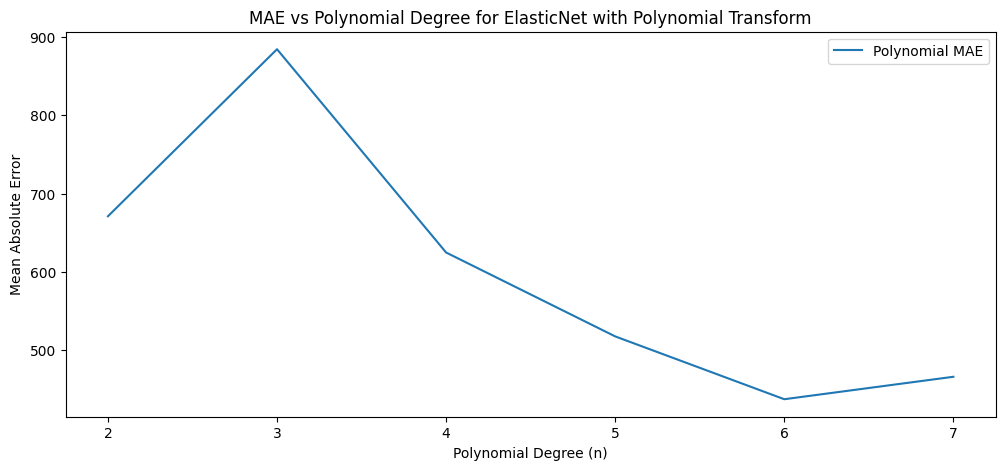

In [23]:
# ElasticNet
def build_pipeline_elasticnet(X, y, n = 2):
    poly_model = make_pipeline(PolynomialFeatures(n, include_bias=False), linear_model.ElasticNet(alpha=1.0, l1_ratio=1, fit_intercept=True, max_iter=10000, tol=0.01)) # use make_pipeline to apply PolynomialFeatures and a Regression model train your dataset
    poly_model.fit(X, y)  

    return poly_model

mae_poly = []
for n in range(2, 8):
    poly_model = build_pipeline_elasticnet(trainX, trainY,n)
    # Compare on training dataset
    poly_pred = poly_model.predict(trainX)
    print(f"mean absolute error of linear model (with poly transform n = {n}) on train set ", mean_absolute_error(y_pred=poly_pred, y_true=trainY) )

    poly_pred = poly_model.predict(testX)
    print(f"mean absolute error of linear model (with poly transform n = {n}) on test set ", mean_absolute_error(y_pred=poly_pred, y_true=testY))
    mae_poly.append(mean_absolute_error(y_pred=poly_pred, y_true=testY))
    
plt.figure(figsize=(12, 5))
plt.plot(range(2, 8), mae_poly, label='Polynomial MAE')
plt.xlabel('Polynomial Degree (n)')
plt.ylabel('Mean Absolute Error')
plt.title('MAE vs Polynomial Degree for ElasticNet with Polynomial Transform')
plt.legend()
plt.show()


Let's try Polynomial of order 2 to compare the previous results. What will the result be if we choose the n order too high?

-> Khi chọn n order quá cao, mô hình sẽ trở nên quá phức tạp và có thể dẫn đến hiện tượng overfitting (như có thể thấy ở các đồ thị trên). Điều này có nghĩa là mô hình sẽ học quá nhiều chi tiết từ dữ liệu huấn luyện, bao gồm cả nhiễu và các điểm dữ liệu không đại diện cho xu hướng chung.  <br>
Kết quả là, mô hình sẽ hoạt động rất tốt trên dữ liệu huấn luyện nhưng sẽ có hiệu suất kém khi áp dụng trên dữ liệu kiểm tra hoặc dữ liệu mới, do nó không thể tổng quát hóa tốt.